In [2]:
# Import necessary libraries
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
# Cell 1: Import necessary libraries
import os
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 94.5MB/s]
Epoch 1/10: 100%|██████████| 118/118 [11:53<00:00,  6.05s/it]


Epoch 1/10 Loss: 2.8242


Epoch 2/10: 100%|██████████| 118/118 [00:25<00:00,  4.63it/s]


Epoch 2/10 Loss: 2.7921


Epoch 3/10: 100%|██████████| 118/118 [00:25<00:00,  4.69it/s]


...

Epoch 9/10: 100%|██████████| 118/118 [00:25<00:00,  4.68it/s]


Epoch 9/10 Loss: 2.7858


Epoch 10/10: 100%|██████████| 118/118 [00:25<00:00,  4.69it/s]


Epoch 10/10 Loss: 2.7893


Extracting Features: 100%|██████████| 118/118 [00:18<00:00,  6.22it/s]


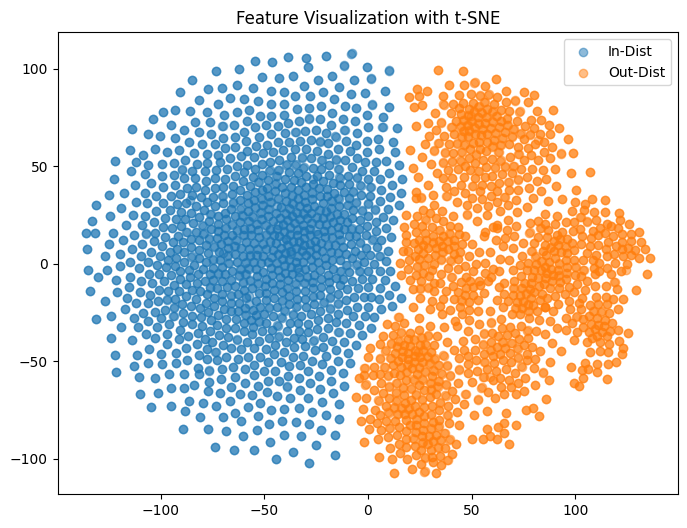

Features saved successfully!


In [3]:
# Cell 1: Import necessary libraries
import os
import numpy as np
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Cell 2: Define the Supervised Contrastive Loss
class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super(SupervisedContrastiveLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        labels = labels.unsqueeze(1)
        mask = torch.eq(labels, labels.T).float().to(device)

        logits = torch.mm(features, features.T) / self.temperature
        logits_max = torch.max(logits, dim=1, keepdim=True).values
        logits = logits - logits_max.detach()

        exp_logits = torch.exp(logits)
        exp_logits_masked = exp_logits * mask

        log_prob = logits - torch.log(exp_logits_masked.sum(dim=1, keepdim=True) + 1e-12)
        mean_log_prob_pos = (mask * log_prob).sum(dim=1) / mask.sum(dim=1)

        loss = -mean_log_prob_pos.mean()
        return loss

# Cell 3: Define the Feature Extractor Model
class FeatureExtractor(nn.Module):
    def __init__(self, backbone="resnet18"):
        super(FeatureExtractor, self).__init__()
        self.backbone = getattr(torchvision.models, backbone)(weights="IMAGENET1K_V1")
        self.feature_layer = nn.Sequential(*list(self.backbone.children())[:-1])  # Remove the final classification layer

    def forward(self, x):
        features = self.feature_layer(x)
        return features.view(features.size(0), -1)

# Cell 4: Data Preparation
# Define paths for in-distribution and out-distribution datasets
in_dist_folder = '/content/drive/MyDrive/DataMonitor'
out_dist_folder = '/content/drive/MyDrive/DataMonitor'

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
in_dist_dataset = datasets.ImageFolder(root=in_dist_folder, transform=transform)
out_dist_dataset = datasets.ImageFolder(root=out_dist_folder, transform=transform)

# Combine datasets and assign labels: 0 for in-distribution, 1 for out-distribution
in_dist_dataset.targets = [0] * len(in_dist_dataset)
out_dist_dataset.targets = [1] * len(out_dist_dataset)
combined_dataset = torch.utils.data.ConcatDataset([in_dist_dataset, out_dist_dataset])

# Create DataLoader
batch_size = 32
data_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# Cell 5: Initialize the Model, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeatureExtractor().to(device)
criterion = SupervisedContrastiveLoss(temperature=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Cell 6: Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, labels in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)
        features = model(images)
        features = nn.functional.normalize(features, p=2, dim=1)  # Normalize feature vectors
        loss = criterion(features, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} Loss: {epoch_loss / len(data_loader):.4f}")

# Cell 7: Extract Features for Visualization
model.eval()
all_features = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(data_loader, desc="Extracting Features"):
        images, labels = images.to(device), labels.to(device)
        features = model(images)
        features = nn.functional.normalize(features, p=2, dim=1)
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_features = np.vstack(all_features)
all_labels = np.hstack(all_labels)

# Cell 8: Visualize Features using t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced_features = tsne.fit_transform(all_features)

plt.figure(figsize=(8, 6))
for label, color in zip([0, 1], ["blue", "orange"]):
    idx = all_labels == label
    plt.scatter(reduced_features[idx, 0], reduced_features[idx, 1], alpha=0.5, label="In-Dist" if label == 0 else "Out-Dist")
plt.title("Feature Visualization with t-SNE")
plt.legend()
plt.show()

# Cell 9: Save Features
in_features = all_features[all_labels == 0]
out_features = all_features[all_labels == 1]

os.makedirs("/content/drive/MyDrive/extracted_features", exist_ok=True)
np.save("/content/drive/MyDrive/extracted_features/in_features.npy", in_features)
np.save("/content/drive/MyDrive/extracted_features/out_features.npy", out_features)
print("Features saved successfully!")


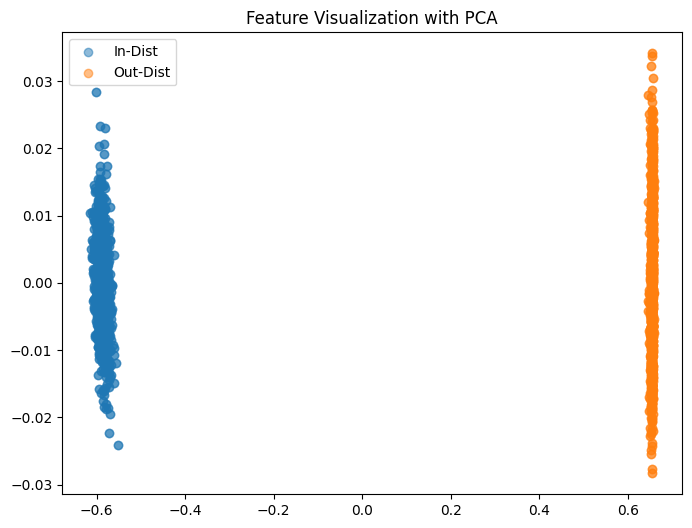

Explained Variance Ratio: [9.9182296e-01 2.1317000e-04]


In [5]:
from sklearn.decomposition import PCA

# Apply PCA to reduce features to 2D
pca = PCA(n_components=2)
pca_features = pca.fit_transform(all_features)

# Plot the PCA results
plt.figure(figsize=(8, 6))
for label, color in zip([0, 1], ["blue", "orange"]):
    idx = all_labels == label
    plt.scatter(pca_features[idx, 0], pca_features[idx, 1], alpha=0.5, label="In-Dist" if label == 0 else "Out-Dist")
plt.title("Feature Visualization with PCA")
plt.legend()
plt.show()

# Print explained variance ratio for PCA components
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 6.1 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


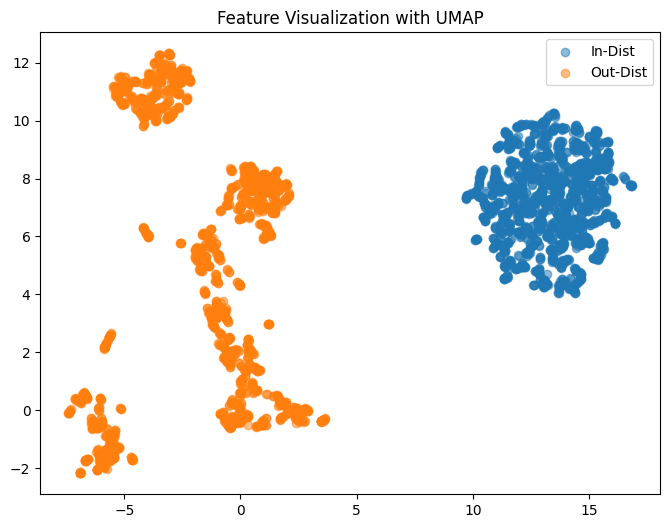

In [7]:
# Apply UMAP
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_features = umap_reducer.fit_transform(all_features)

# Plot UMAP Visualization
plt.figure(figsize=(8, 6))
for label, color in zip([0, 1], ["blue", "orange"]):
    idx = all_labels == label
    plt.scatter(umap_features[idx, 0], umap_features[idx, 1], alpha=0.5, label="In-Dist" if label == 0 else "Out-Dist")
plt.title("Feature Visualization with UMAP")
plt.legend()
plt.show()
